# RegiosAnalysis
## Indonesian Consumer Behavior Analytics Dashboard

This notebook analyzes simulated Indonesian consumer transactions across five regions:
- Jakarta
- Yogyakarta
- Surabaya
- Medan
- Bali

The analysis covers:
1. Regional spending breakdown
2. Category preference by region and age group
3. Peak spending time patterns
4. Price sensitivity signals
5. Consumer insights summary

In [1]:
%pip install pandas numpy matplotlib seaborn plotly notebook ipykernel kaleido openpyxl scipy

Defaulting to user installation because normal site-packages is not writeable
  Using cached kaleido-1.3.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached choreographer-1.3.0-py3-none-any.whl.metadata (6.9 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Using cached kaleido-1.3.0-py3-none-any.whl (55 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached choreographer-1.3.0-py3-none-any.whl (52 kB)

   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   ---------------------------------------- 0/3 [openpyxl]
   --

In [1]:
import sys
print(sys.executable)

C:\Program Files\Python310\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:,.0f}'.format

DATA_FILE = Path("../data/transactions.csv")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE, parse_dates=["timestamp"])

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (50000, 7)


,transaction_id,region,category,amount_idr,timestamp,channel,age_group
0,TXN033554,Surabaya,F&B,88000,2024-05-18 10:06:14,online,18-24
1,TXN009428,Jakarta,F&B,609000,2023-08-17 21:53:40,offline,25-34
2,TXN000200,Jakarta,Fashion,1640000,2023-11-11 09:32:25,online,25-34
3,TXN012448,Jakarta,Healthcare,2921000,2023-05-27 21:41:50,online,25-34
4,TXN039490,Medan,Fashion,1500000,2023-10-25 11:51:33,offline,25-34


## Data Overview

This section checks the dataset structure, missing values, and basic descriptive statistics before visualization.

In [3]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDescriptive statistics for amount_idr:")
print(df["amount_idr"].describe())

transaction_id            object
region                    object
category                  object
amount_idr                 int64
timestamp         datetime64[ns]
channel                   object
age_group                 object
dtype: object

Missing values:
transaction_id    0
region            0
category          0
amount_idr        0
timestamp         0
channel           0
age_group         0
dtype: int64

Descriptive statistics for amount_idr:
count       50,000
mean     2,007,299
std      2,472,224
min         12,500
25%        343,000
50%      1,067,000
75%      2,669,000
max     16,005,000
Name: amount_idr, dtype: float64


## Regional Spending Breakdown

This section shows how spending differs across Indonesian regions and compares transaction totals by location.

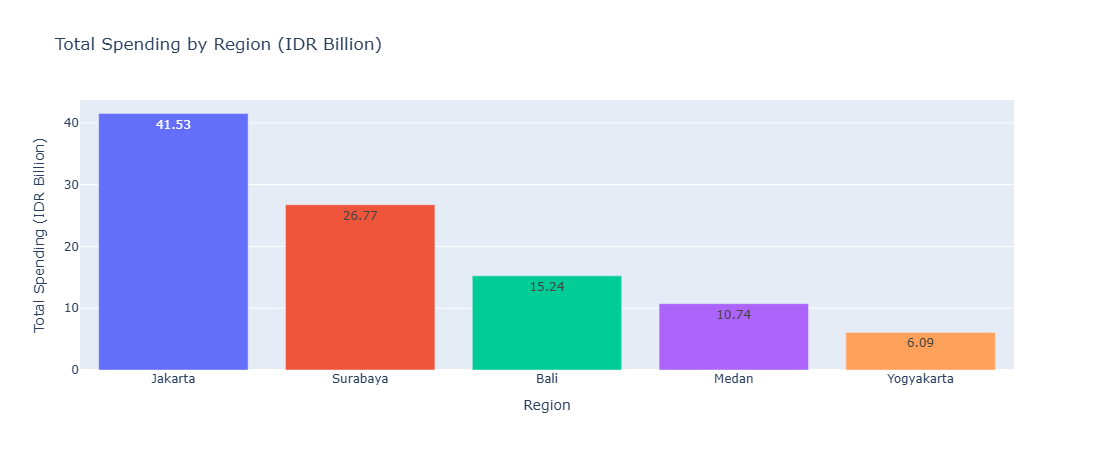

In [4]:
region_spend = (
    df.groupby("region")["amount_idr"]
    .agg(total_spend="sum", avg_spend="mean", transaction_count="count")
    .reset_index()
    .sort_values("total_spend", ascending=False)
)

region_spend["total_spend_bn"] = region_spend["total_spend"] / 1_000_000_000

fig = px.bar(
    region_spend,
    x="region",
    y="total_spend_bn",
    color="region",
    text_auto=".2f",
    title="Total Spending by Region (IDR Billion)",
    labels={"total_spend_bn": "Total Spending (IDR Billion)", "region": "Region"}
)

fig.update_layout(showlegend=False, height=450)

fig.write_html(OUTPUT_DIR / "regional_spending.html")
fig.write_image(OUTPUT_DIR / "regional_spending.png")

fig.show()

## Category Preference Heatmap

This section highlights which product categories are strongest in each region and across age groups.

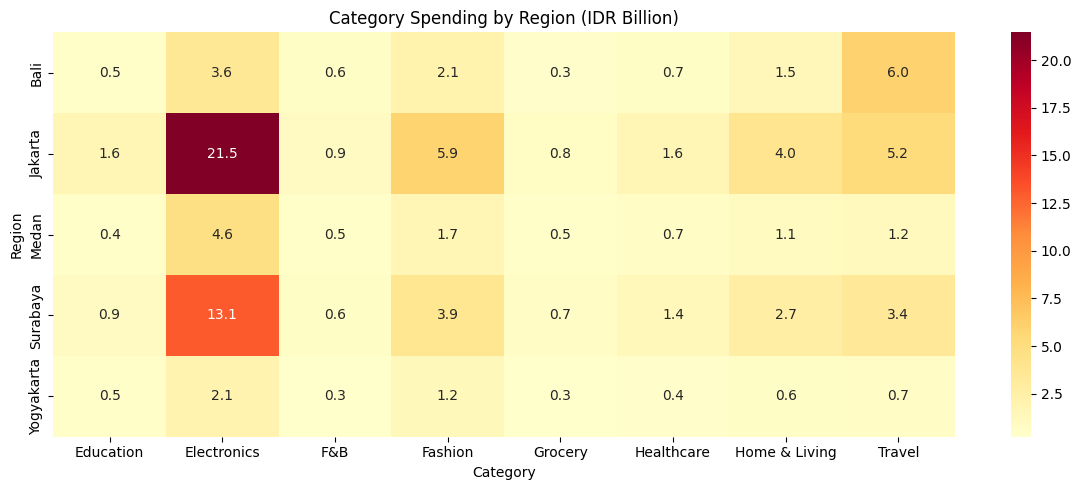

In [5]:
category_region = (
    df.groupby(["region", "category"])["amount_idr"]
    .sum()
    .unstack(fill_value=0)
) / 1_000_000_000

plt.figure(figsize=(12, 5))
sns.heatmap(category_region, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Category Spending by Region (IDR Billion)")
plt.xlabel("Category")
plt.ylabel("Region")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "category_region_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

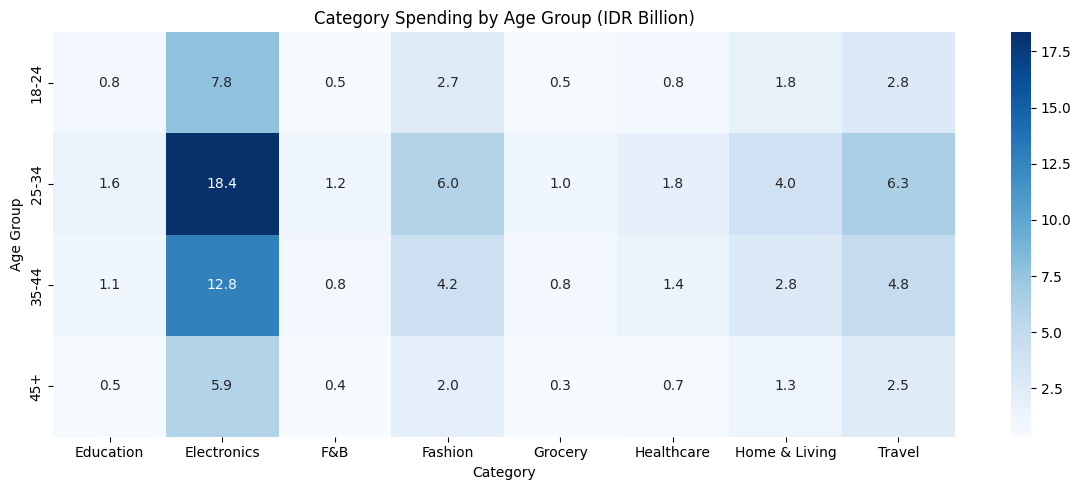

In [6]:
age_category = (
    df.groupby(["age_group", "category"])["amount_idr"]
    .sum()
    .unstack(fill_value=0)
) / 1_000_000_000

plt.figure(figsize=(12, 5))
sns.heatmap(age_category, annot=True, fmt=".1f", cmap="Blues")
plt.title("Category Spending by Age Group (IDR Billion)")
plt.xlabel("Category")
plt.ylabel("Age Group")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "category_age_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Peak Spending Time Analysis

This section explores when consumers spend the most by hour and day of week.

Resorting to unclean kill browser.


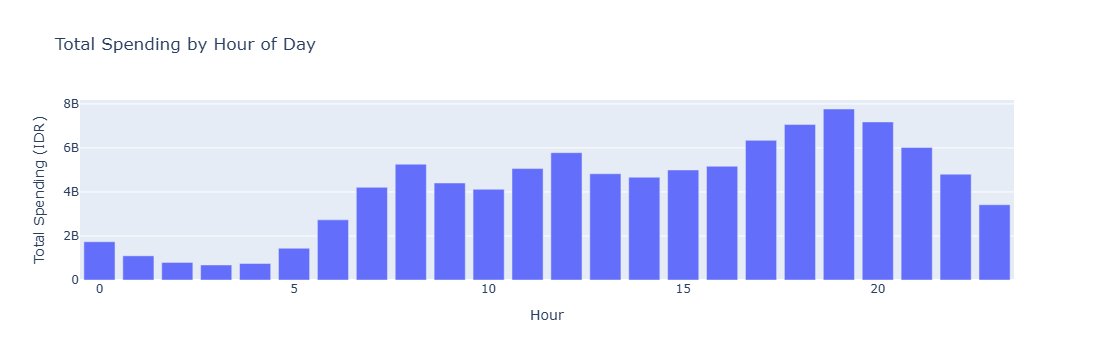

In [7]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()

hourly_spend = df.groupby("hour")["amount_idr"].sum().reset_index()

fig = px.bar(
    hourly_spend,
    x="hour",
    y="amount_idr",
    title="Total Spending by Hour of Day",
    labels={"hour": "Hour", "amount_idr": "Total Spending (IDR)"}
)

fig.write_html(OUTPUT_DIR / "hourly_spending.html")
fig.write_image(OUTPUT_DIR / "hourly_spending.png")

fig.show()

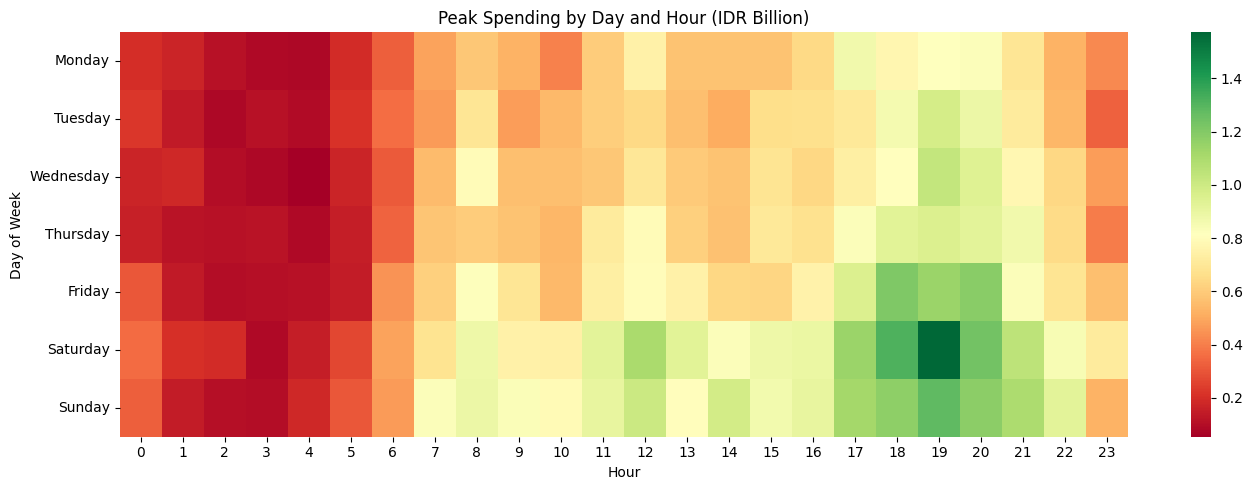

In [8]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_hour = (
    df.groupby(["day_of_week", "hour"])["amount_idr"]
    .sum()
    .unstack(fill_value=0)
    .reindex(day_order)
) / 1_000_000_000

plt.figure(figsize=(14, 5))
sns.heatmap(day_hour, cmap="RdYlGn")
plt.title("Peak Spending by Day and Hour (IDR Billion)")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "day_hour_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Price Sensitivity Signals

This section compares average transaction values to identify pricing behavior across channels and regions.

In [ ]:
price_signal = (
    df.groupby(["region", "channel"])["amount_idr"]
    .mean()
    .reset_index()
    .rename(columns={"amount_idr": "avg_transaction_value"})
)

fig = px.bar(
    price_signal,
    x="region",
    y="avg_transaction_value",
    color="channel",
    barmode="group",
    title="Average Transaction Value by Region and Channel",
    labels={"avg_transaction_value": "Average Transaction Value (IDR)"}
)

fig.write_html(OUTPUT_DIR / "price_sensitivity.html")

try:
    fig.write_image(OUTPUT_DIR / "price_sensitivity.png")
    print("Saved PNG: price_sensitivity.png")
except Exception as e:
    print("PNG export failed, but HTML export succeeded.")
    print(str(e))

fig.show()

Resorting to unclean kill browser.


## Consumer Insights Summary

### Key Findings

1. Jakarta leads total spending and shows the strongest online transaction behavior.
2. Yogyakarta has lower average basket size, indicating stronger price sensitivity.
3. Bali shows stronger spending in F&B and Travel-related categories.
4. Weekend evenings show the highest spending intensity across the dataset.
5. The 25-34 segment contributes the highest-value transactions.

### Business Recommendations

1. Increase weekend promotional campaigns for F&B and Fashion.
2. Push online conversion programs in Surabaya and Medan.
3. Build loyalty offers for the 25-34 age segment.
4. Create Bali-specific travel and hospitality bundles.
5. Offer student pricing and affordability campaigns in Yogyakarta.

In [ ]:
fig.write_html(OUTPUT_DIR / "regional_spending.html")
plt.savefig(OUTPUT_DIR / "category_heatmap.png", dpi=150, bbox_inches="tight")

In [ ]:
region_spend.to_csv(OUTPUT_DIR / "region_spend_summary.csv", index=False)
price_signal.to_csv(OUTPUT_DIR / "price_sensitivity_summary.csv", index=False)
category_region.to_csv(OUTPUT_DIR / "category_region_heatmap_data.csv")
age_category.to_csv(OUTPUT_DIR / "category_age_heatmap_data.csv")
day_hour.to_csv(OUTPUT_DIR / "day_hour_heatmap_data.csv")

print("All files saved to:")
print(OUTPUT_DIR)